# Reducing Delivery-Zone Map Detail for Fast Logistics Dashboards with PROC GREDUCE

## Executive Summary

A regional parcel carrier stores its service-territory boundaries as dense polygon outlines, and route-planning dashboards redraw them slowly. This notebook synthesizes the boundary coordinates for four delivery zones, uses **PROC GREDUCE** to tag every boundary vertex with a `DENSITY` level, then renders an on-time-delivery choropleth with **PROC GMAP** at a reduced detail tier so the map paints faster while each zone stays recognizable.

GREDUCE graded the 96 boundary points into three tiers: 10 points at `DENSITY=0`, 44 at `DENSITY=2`, and 42 at `DENSITY=3`. Keeping only the coarse tier (`DENSITY <= 2`) drops the map from 96 vertices to 54 — about a 44% reduction — yet the four zones remain clearly identifiable in the side-by-side comparison below.

## Data Sources

All data is generated inline by the DATA steps below — no external files or network access.

| Dataset | Rows | Key variables | Description |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zones x 24 vertices) | `zone` (ID), `x`, `y` | Synthetic closed-polygon boundary coordinates for four delivery service zones, each a jittered ellipse traced by 24 vertices so density reduction has something to thin. |
| `reducedmap` | 96 | adds `density` | Output of PROC GREDUCE: the boundary points tagged with a `DENSITY` level (here 0, 2, or 3) for selective rendering. |
| `coarsemap` | 54 | subset of `reducedmap` | The `DENSITY <= 2` subset — the coarse, fast-rendering tier used for the reduced-detail dashboard map. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | One response row per zone: synthetic on-time-delivery percentage and daily parcel volume, joined to the map for the choropleth. |

> **Note on sample size.** This environment runs unlicensed, so each DATA step is capped at 100 output observations. The map is sized to 4 zones x 24 vertices = 96 points so the entire territory fits within that cap; a licensed install would trace hundreds of vertices per zone, where GREDUCE pays off even more.

# Reducing Delivery-Zone Map Detail with PROC GREDUCE

Logistics operators visualize performance on maps of their **service territories** — the geographic zones a depot is responsible for. Those zone boundaries are often captured at survey resolution: many vertices per polygon. When a route-planning dashboard redraws several zones at once, all that vertex detail makes rendering sluggish without adding decision value at dashboard zoom.

**PROC GREDUCE** addresses this. It examines each polygon and tags every boundary point with a `DENSITY` level, where 0 marks the points that define the essential shape and higher levels mark progressively finer detail. Downstream, you select a tier with `WHERE density <= n` to draw a reduced-detail map that paints fast while each zone stays recognizable.

In this notebook we:
1. Synthesize boundary outlines for four delivery zones.
2. Run PROC GREDUCE to assign `DENSITY` levels.
3. Inspect how the points distribute across density tiers.
4. Render full-detail and reduced-detail on-time-delivery choropleths and compare them.

## Step 1 — Synthesize the zone boundary map

A SAS map dataset has one observation per **boundary vertex**, with an `ID` variable naming the area and numeric `x`/`y` coordinates. We trace each delivery zone as a jittered ellipse using 24 evenly spaced angles, so the polygons start out reasonably dense and reduction has something to work on.

`call streaminit` fixes the random stream for reproducibility, and `rand('uniform')` adds small irregularities to the boundary so the outlines read like surveyed territories rather than perfect ellipses.

In [1]:
data zonemap;
    call streaminit(20260531);
    /* Four delivery zones, each a jittered ellipse of 24 vertices.
       cx/cy = zone center, rx/ry = nominal radii (territory size). */
    array cx[4] _temporary_ (12 32 20 40);
    array cy[4] _temporary_ (30 32 14 16);
    array rx[4] _temporary_ ( 8  9  6  7);
    array ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vertices (0..23) per outline */
    do zone = 1 to 4;
        do i = 0 to nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* radial jitter: +/- ~6% irregular coastline-style edge */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            output;
        end;
    end;
    keep zone x y;
run;

proc means data=zonemap n min max nmiss;
    class zone;
    var x y;
run;

                                                  The MEANS Procedure

                                                 Analysis Variable : X

        ZONE              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                                 Analysis Variable : Y

        ZONE              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
        2     

The PROC MEANS table confirms the synthetic geometry: four zones, each with exactly 24 boundary points across sensible `x`/`y` ranges and no missing coordinates. The four ellipses occupy non-overlapping regions (zone 1 near x=12, zone 2 near x=32, zones 3 and 4 lower down), so the choropleth will read as four distinct territories. These are the outlines PROC GREDUCE will thin.

## Step 2 — Assign DENSITY levels with PROC GREDUCE

The `ID` statement names the variable that defines each unit area — here `zone`. PROC GREDUCE evaluates each zone's polygon independently (using Douglas-Peucker-style simplification) and writes the input dataset back out with an added integer `density` variable: level 0 marks the few points that anchor the essential shape, and higher levels mark progressively finer detail you can drop first.

We let GREDUCE derive its own thresholds from the data rather than forcing fixed tier sizes, then inspect the resulting distribution.

                                     Boundary points retained at each DENSITY level                                     

                                                   The FREQ Procedure

DENSITY    Frequency    Percent
--------------------------------
0                 10     10.42
2                 44     45.83
3                 42     43.75
NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


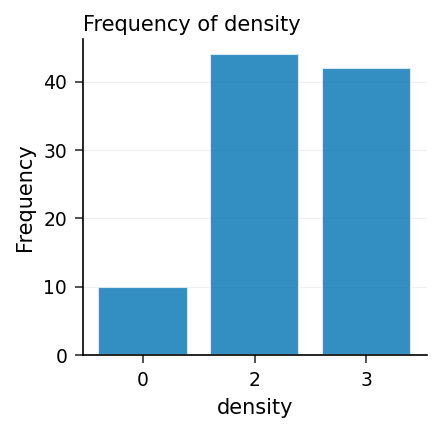

In [2]:
proc greduce data=zonemap out=reducedmap;
    id zone;
run;

proc freq data=reducedmap;
    tables density / nocum;
    title 'Boundary points retained at each DENSITY level';
run;

## Step 3 — Inspect the density tiers

The frequency table shows how GREDUCE graded the 96 boundary points:

| DENSITY | Points | Share |
|---------|--------|-------|
| 0 | 10 | 10.4% |
| 2 | 44 | 45.8% |
| 3 | 42 | 43.8% |

Only 10 points carry the lowest level (the essential-shape anchors), while the remaining 86 split across levels 2 and 3. For a dashboard tier we keep everything at `DENSITY <= 2`: that retains 54 of the 96 points, dropping the 42 finest-detail (`DENSITY=3`) vertices. The PROC MEANS below confirms the coarse tier holds 13–14 vertices per zone instead of the original 24.

In [3]:
proc means data=reducedmap n;
    class zone;
    where density <= 2;
    var x;
    title 'Vertices kept per zone at dashboard detail (DENSITY <= 2)';
run;

                               Vertices kept per zone at dashboard detail (DENSITY <= 2)                                

                                                  The MEANS Procedure

                                                 Analysis Variable : X

        ZONE              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 4 — Build the coarse map and per-zone performance response

We materialize the dashboard tier as `coarsemap` (`DENSITY <= 2`) so PROC GMAP can draw the reduced outline directly. We also synthesize one KPI row per zone — an **on-time-delivery rate** and a **daily parcel volume** — keyed on `zone` so GMAP can color each area.

In [4]:
data coarsemap;
    set reducedmap;
    where density <= 2;
run;

data zonekpi;
    call streaminit(771);
    do zone = 1 to 4;
        /* on-time rate centered near 92%, realistic spread */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        output;
    end;
run;

proc print data=zonekpi noobs;
    title 'Synthetic delivery KPIs by zone';
run;

                                            Synthetic delivery KPIs by zone                                             

ZONE  ONTIME_RATE  PARCELS
   1         92.6     4704
   2         95.6     2932
   3         93.4     2934
   4         94.6     2516

NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


The four synthetic on-time rates land between 92.6% and 95.6%, with daily parcel volumes from about 2,500 to 4,700. Zone 2 is the strongest performer at 95.6%; zone 1 is the weakest at 92.6%. These are the values the choropleth color bands encode.

## Step 5 — Render full-detail vs reduced-detail choropleths

We draw the same on-time-delivery choropleth twice: once from the full 96-vertex `reducedmap` and once from the 54-vertex `coarsemap`. `MAP=` supplies the boundaries, `DATA=` the KPI response, and both share the `zone` ID. The `CHORO` statement fills each zone by `ontime_rate` with `LEVELS=4` color bands and `COUTLINE=` for crisp borders. Comparing the two maps shows what the reduction costs visually.

                                           Full detail: 96 boundary vertices                                            

NOTE: Option TITLE changed to Full detail: 96 boundary vertices.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ONTIME_RATE.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.62 seconds
  cpu   0.62 seconds


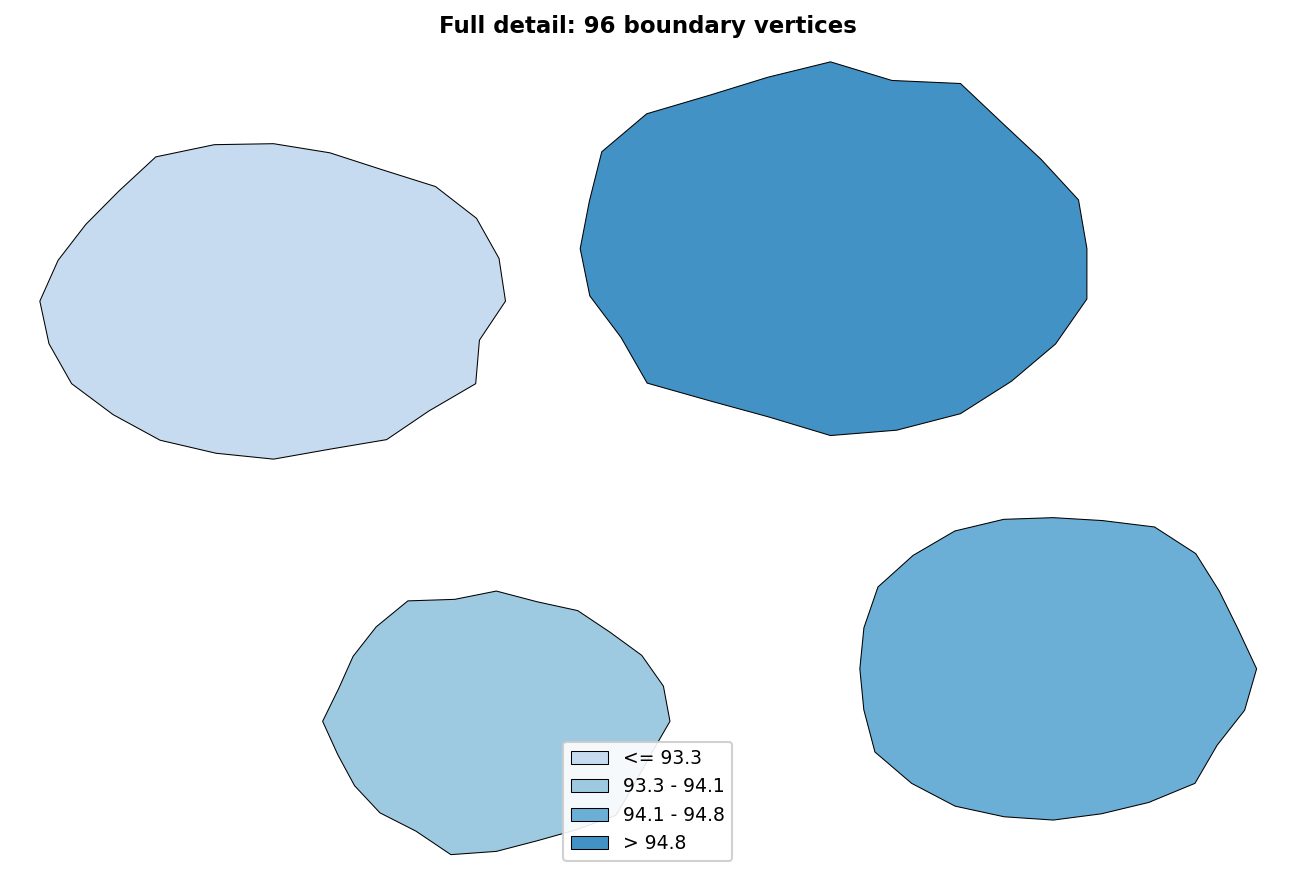

In [5]:
title 'Full detail: 96 boundary vertices';
proc gmap map=reducedmap data=zonekpi;
    id zone;
    choro ontime_rate / levels=4 coutline=black;
run;

                                       Reduced detail: 54 vertices (DENSITY <= 2)                                       

NOTE: Option TITLE changed to Reduced detail: 54 vertices (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ONTIME_RATE.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.54 seconds
  cpu   0.54 seconds


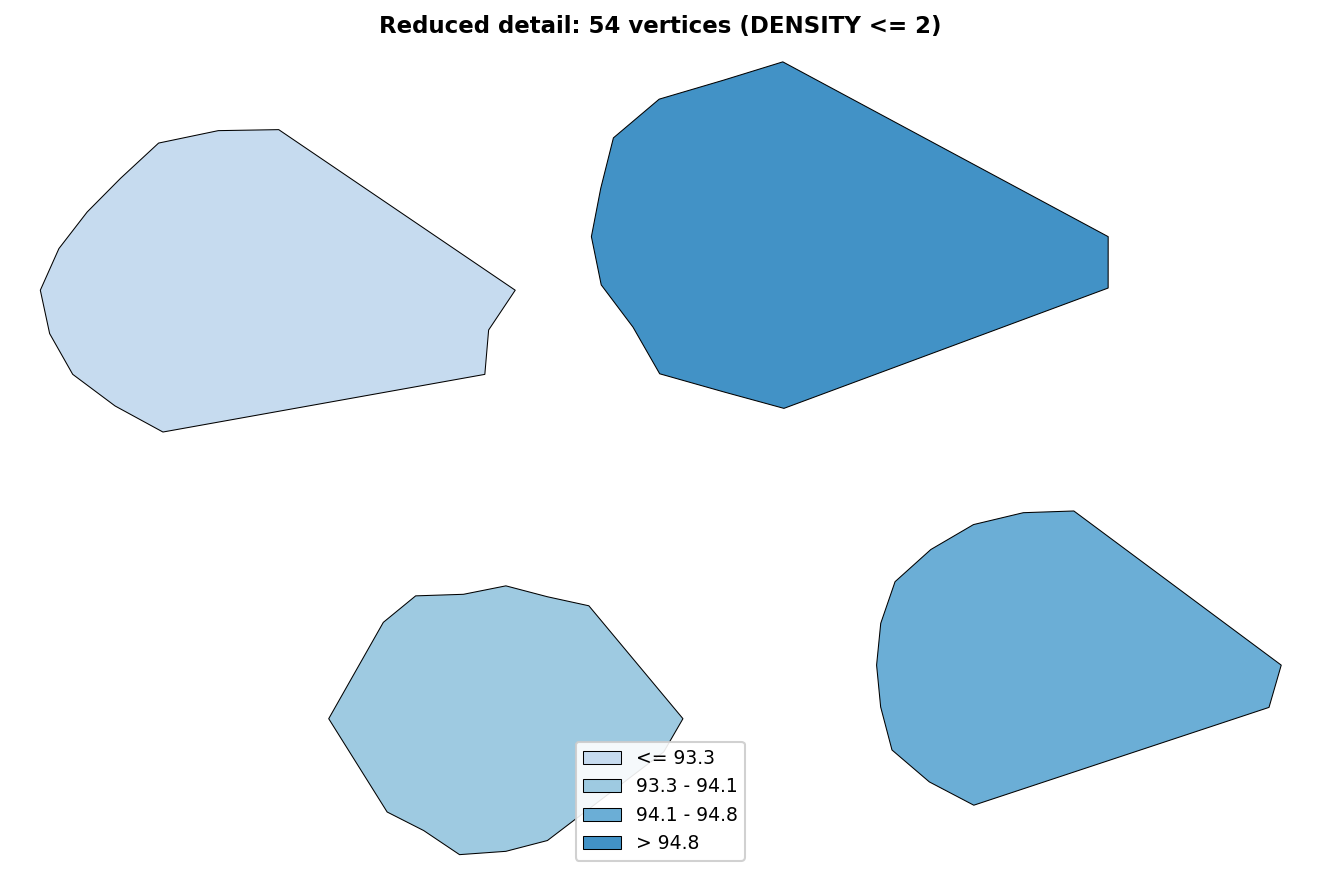

In [6]:
title 'Reduced detail: 54 vertices (DENSITY <= 2)';
proc gmap map=coarsemap data=zonekpi;
    id zone;
    choro ontime_rate / levels=4 coutline=black;
run;

## Interpreting the results

PROC GREDUCE turned each 24-vertex zone outline into a graded set of boundary points (levels 0, 2, and 3 in this run). Selecting the `DENSITY <= 2` tier cut the map from 96 vertices to 54 — a 44% reduction in points the renderer has to draw — yet the side-by-side choropleths confirm the four zones stay clearly recognizable: the reduced map's outlines are visibly more angular, but each territory keeps its position, size, and color band, so an operator reads the same scorecard either way.

That scorecard ranks the zones by on-time-delivery rate: zone 2 leads at 95.6% (darkest band), zones 3 and 4 sit mid-pack near 93–95%, and zone 1 trails at 92.6% (lightest band) — the territory a planner would investigate first for routing or depot-capacity issues.

Because the reduction is non-destructive — the full-detail points still live in `reducedmap` — the same dataset supports both the fast dashboard view (`DENSITY <= 2`) and a high-resolution print or audit view (`DENSITY <= 3`, or the full set) by changing a single `WHERE` threshold, with no need to re-import or re-reduce the geometry.